In [1]:
# import python library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload Dataset form Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

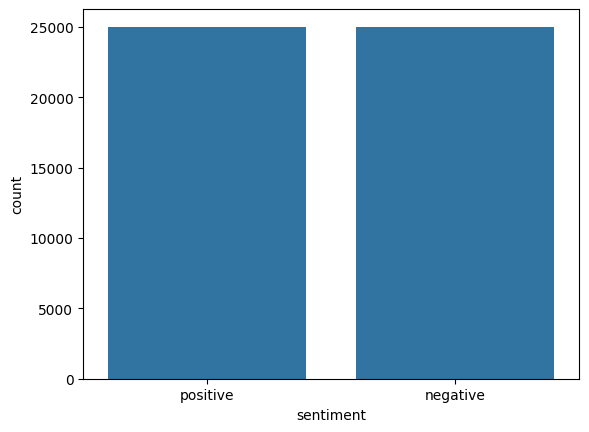

In [5]:
# Plot Target Feature
sns.countplot(x='sentiment', data=df)
plt.show()

In [6]:
# Imbalance Target Feature
pr = df[df['sentiment']=='positive'][:1000]
nr = df[df['sentiment']=='negative'][:700]

In [7]:
# Observe Target Feature after imbalance
new_df = pd.concat([pr,nr], axis=0)
new_df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
1418,There are two kinds of 1950s musicals. First y...,negative
1420,"Okay people, I have to agree with almost every...",negative
1421,"If Alien, Jurassic Park and countless other sc...",negative
1422,I'd like to think myself as a fairly open mind...,negative


In [8]:
# Rename Data Frame
df = new_df
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
1418,There are two kinds of 1950s musicals. First y...,negative
1420,"Okay people, I have to agree with almost every...",negative
1421,"If Alien, Jurassic Park and countless other sc...",negative
1422,I'd like to think myself as a fairly open mind...,negative


In [9]:
# Imbalance Data Fream Target Feature's value counts
df['sentiment'].value_counts()

sentiment
positive    1000
negative     700
Name: count, dtype: int64

In [10]:
df.shape

(1700, 2)

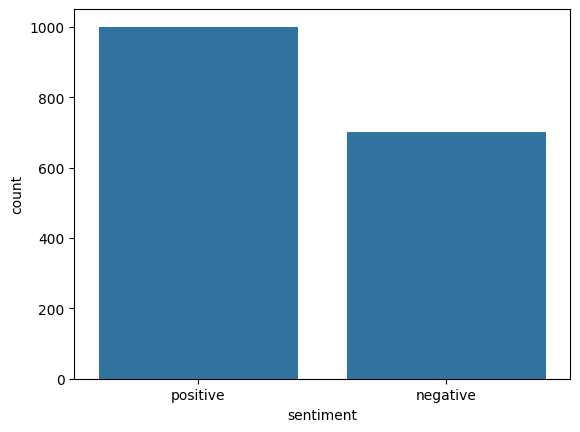

In [11]:
# Plot Target Feature After imbalance Data
sns.countplot(x='sentiment', data=df)
plt.show()

In [14]:
# Create list for positive and negative sentiment
positive_review = list(df[df['sentiment']=='positive']['review'])
negative_review = list(df[df['sentiment']=='negative']['review'])

In [15]:
# Apply Word Cloud
from wordcloud import STOPWORDS, WordCloud
wordcloud = set(STOPWORDS)
wordcloud

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [16]:
# Create a function to vidualize Word Cloud
def create_cloud(string, title=None):
    cloud = WordCloud(height=1080,
                      width=1920,
                      background_color='black',
                      min_font_size=10,
                      stopwords=STOPWORDS).generate(string)
    plt.figure(figsize=(10,20))
    plt.imshow(cloud)
    plt.axis("off")
    if title:
        plt.title(title, fontdict={'fontsize':24})
    plt.show()

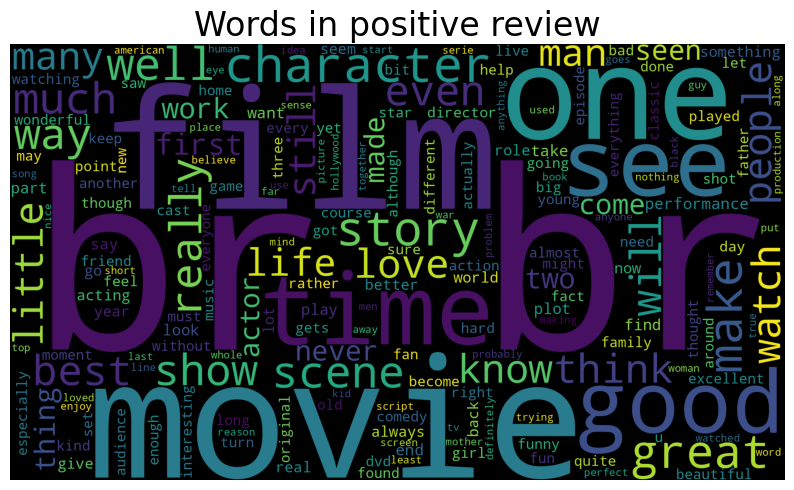

In [17]:
# Vidualize Words of Positive Review
create_cloud(' '.join(positive_review).lower(), 'Words in positive review')

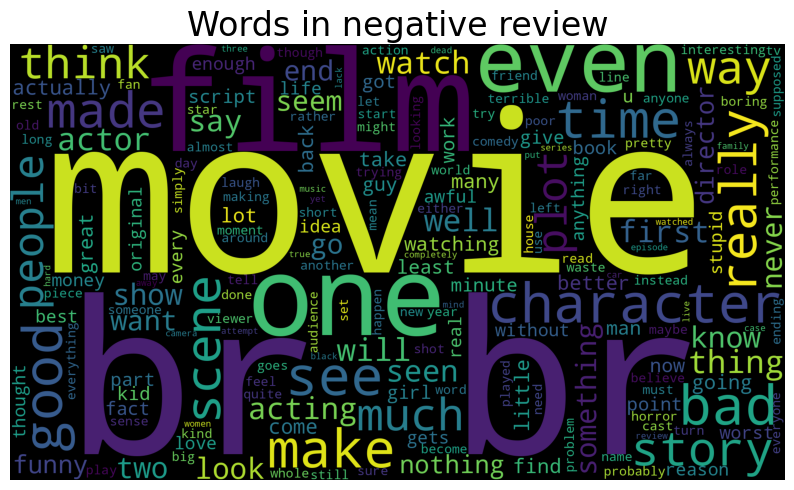

In [18]:
# Vidualize Words of Negative Review
create_cloud(' '.join(negative_review).lower(), 'Words in negative review')

In [19]:
# Create function to cleanup sentance
def text_processing(data):
    from bs4 import BeautifulSoup
    import re
    def decontracted(phrase):
        # specific
        phrase= re.sub(r'<br /><br />',' ',phrase)
        phrase = re.sub(r"won't", "will not", phrase)
        phrase = re.sub(r"can\'t", "can not", phrase)

        # general
        phrase = re.sub(r"n\'t", " not", phrase)
        phrase = re.sub(r"\'re", " are", phrase)
        phrase = re.sub(r"\'s", " is", phrase)
        phrase = re.sub(r"\'d", " would", phrase)
        phrase = re.sub(r"\'ll", " will", phrase)
        phrase = re.sub(r"\'t", " not", phrase)
        phrase = re.sub(r"\'ve", " have", phrase)
        phrase = re.sub(r"\'m", " am", phrase)
        phrase = re.sub(r'"', " ", phrase)
        return phrase
    stopwords=set(STOPWORDS)

    # Combining all the above sentence
    from tqdm import tqdm
    preprocessed_reviews = []
    # tqdm is for printing the status bar
    for sentance in tqdm(data['review'].values):
        sentance = re.sub(r"http\S+", "", sentance)
        sentance = BeautifulSoup(sentance, 'lxml').get_text()
        sentance = decontracted(sentance)
        sentance = re.sub("\S*\d\S*", "", sentance).strip()
        # https://gist.github.com/sebleier/554280
        sentance = ' '.join(e.lower() for e in sentance.split() if e not in stopwords)
        preprocessed_reviews.append(sentance.strip())

    from nltk.stem import PorterStemmer

    porter = PorterStemmer()
    list_of_sentence=[]
    for  sentence in preprocessed_reviews:
        words_in_sentence=[]
        for words in sentence.split():
            words_in_sentence.append(porter.stem(words))

        list_of_sentence.append(' '.join(words_in_sentence))
    return(list_of_sentence)

In [20]:
# Run the function to process the data
x=text_processing(df)

 23%|██▎       | 396/1700 [00:00<00:01, 1055.48it/s]<ipython-input-19-d415253b934c>:30: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  sentance = BeautifulSoup(sentance, 'lxml').get_text()
100%|██████████| 1700/1700 [00:01<00:00, 1421.45it/s]


In [21]:
# Add a mew column in the data frame
df['clean_review']=x

In [22]:
df

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one review mention watch oz episod will hooked...
1,A wonderful little production. <br /><br />The...,positive,a wonder littl production. the film techniqu u...
2,I thought this was a wonderful way to spend ti...,positive,i thought wonder way spend time hot summer wee...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visual stun film...
5,"Probably my all-time favorite movie, a story o...",positive,"probabl all-tim favorit movie, stori selflessn..."
...,...,...,...
1418,There are two kinds of 1950s musicals. First y...,negative,there two kind musicals. first glossi mgm prod...
1420,"Okay people, I have to agree with almost every...",negative,"okay people, i agre almost everyon review here..."
1421,"If Alien, Jurassic Park and countless other sc...",negative,"if alien, jurass park countless sci fi horror ..."
1422,I'd like to think myself as a fairly open mind...,negative,i think fairli open mind guy take lot(!) disli...


In [23]:
# Define input and output/target features
X = df['clean_review']
Y = df['sentiment']

In [24]:
# Convert sentiment Data string to numeric value
Y =list(Y)
for i in range(len(Y)):
  if Y[i] == 'positive':
    Y[i] = 1
  else:
    Y[i] = 0
df['sentiment_score'] = Y
Y = df['sentiment_score']

In [25]:
df

,review,sentiment,clean_review,sentiment_score
0,One of the other reviewers has mentioned that ...,positive,one review mention watch oz episod will hooked...,1
1,A wonderful little production. <br /><br />The...,positive,a wonder littl production. the film techniqu u...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought wonder way spend time hot summer wee...,1
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visual stun film...,1
5,"Probably my all-time favorite movie, a story o...",positive,"probabl all-tim favorit movie, stori selflessn...",1
...,...,...,...,...
1418,There are two kinds of 1950s musicals. First y...,negative,there two kind musicals. first glossi mgm prod...,0
1420,"Okay people, I have to agree with almost every...",negative,"okay people, i agre almost everyon review here...",0
1421,"If Alien, Jurassic Park and countless other sc...",negative,"if alien, jurass park countless sci fi horror ...",0
1422,I'd like to think myself as a fairly open mind...,negative,i think fairli open mind guy take lot(!) disli...,0


In [26]:
# Apply Count Vectorizer to embed the words
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

In [27]:
# Fit and Transform Count Vectorizer for Visualization
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(X)

In [28]:
# Apply TruncatedSVD
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100)

In [29]:
# Specify the number of components from Review column
X_svd = svd.fit_transform(X_counts)

In [30]:
# Apply SMOTE to balance target feature
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [31]:
# Run the SMOTE to balance target feature
X_resampled, y_resampled = smote.fit_resample(X_svd, Y)

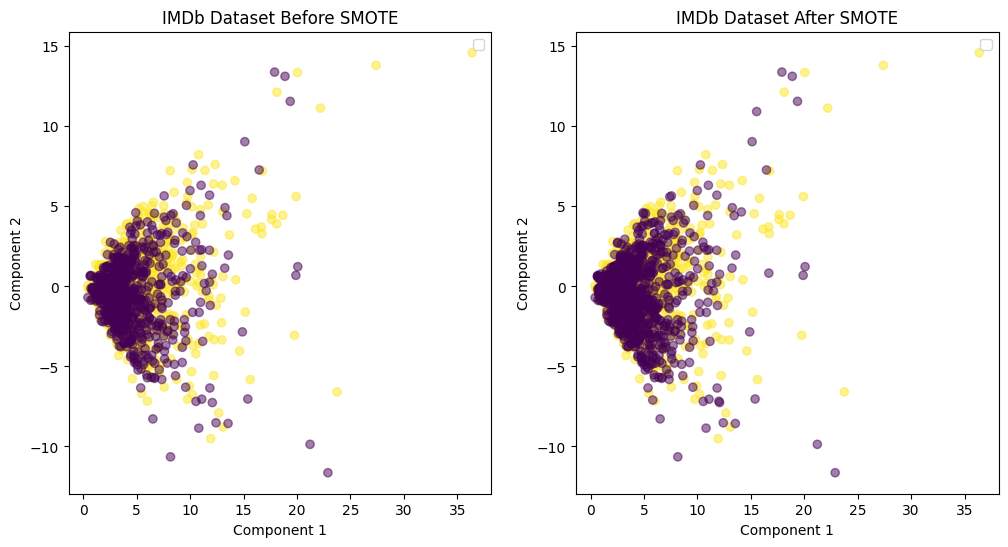

In [32]:
# 2D Visualization - Before SMOTE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=Y, cmap='viridis', alpha=0.5)
plt.title('IMDb Dataset Before SMOTE')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
#plt.colorbar(label='Class')
plt.legend()
#plt.show()

# 2D Visualization - After SMOTE
#plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 2)
plt.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='viridis', alpha=0.5)
plt.title('IMDb Dataset After SMOTE')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
#plt.colorbar(label='Class')
plt.legend()
#plt.show()

In [33]:
# Split train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [34]:
# Fit and Transform Count Vectorizer
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)

In [35]:
X_train_bow.shape

(1360, 18522)

In [36]:
X_train_bow.toarray()[0]

array([0, 0, 0, ..., 0, 0, 0])

In [37]:
X_train

731     thi filmmak want make movi without stori tell ...
615     it start seriou social commentari quickli make...
340     i debat movi chose inglouri basterd due amazin...
1288    saw movi total love charact great . definit ki...
928     after high darkplac never conceiv hol adoby ab...
                              ...                        
239     apparently, the mutil man guy wander land perf...
553     thi movi pretti much sucked. i armi soldier de...
1685    it unbeliev fourth better second third. after ...
921     zzzzzzzzzzzzzzzzzz ! if imdb allow one-word re...
223     when open shot u.s. marin serious disrespect u...
Name: clean_review, Length: 1360, dtype: object

In [38]:
list(y_test).count(1)

214

In [39]:
# Run the SMOTE to balance target feature
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_bow, y_train)

In [40]:
list(y_train).count(1), list(y_resampled).count(1)

(786, 786)

In [41]:
# Apply KNN with Metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

In [43]:
# Observe KNN performance and pick the best performed K value
accuracy_train_list = []
accuracy_test_list  = []
f1_train_list       = []
f1_test_list        = []

for i in range(10, 25):
  print('K', i)

  KNN = KNeighborsClassifier(n_neighbors=i)
  KNN.fit(X_resampled, y_resampled)

  y_pred_train = KNN.predict(X_train_bow)
  accuracy_train = accuracy_score(y_pred_train, y_train)
  accuracy_train_list.append(accuracy_train)

  f1_train = f1_score(y_pred_train, y_train)
  f1_train_list.append(f1_train)

  y_pred_test = KNN.predict(X_test_bow)
  accuracy_test = accuracy_score(y_pred_test, y_test)
  accuracy_test_list.append(accuracy_test)

  f1_test = f1_score(y_pred_test, y_test)
  f1_test_list.append(f1_test)

  print(accuracy_train, accuracy_test)
  print(f1_train, f1_test, '\n')

K 10
0.4279411764705882 0.37941176470588234
0.022613065326633167 0.027649769585253458 

K 11
0.4279411764705882 0.37941176470588234
0.02506265664160401 0.027649769585253458 

K 12
0.4264705882352941 0.3764705882352941
0.017632241813602016 0.018518518518518517 

K 13
0.425 0.3764705882352941
0.017587939698492462 0.018518518518518517 

K 14
0.4264705882352941 0.3764705882352941
0.017632241813602016 0.018518518518518517 

K 15
0.42573529411764705 0.3764705882352941
0.01761006289308176 0.018518518518518517 

K 16
0.425 0.3764705882352941
0.012626262626262624 0.018518518518518517 

K 17
0.425 0.3764705882352941
0.012626262626262624 0.018518518518518517 

K 18
0.42426470588235293 0.3764705882352941
0.010113780025284451 0.018518518518518517 

K 19
0.42426470588235293 0.3764705882352941
0.012610340479192936 0.018518518518518517 

K 20
0.4235294117647059 0.3735294117647059
0.0101010101010101 0.009302325581395347 

K 21
0.4235294117647059 0.3764705882352941
0.0101010101010101 0.01851851851851851

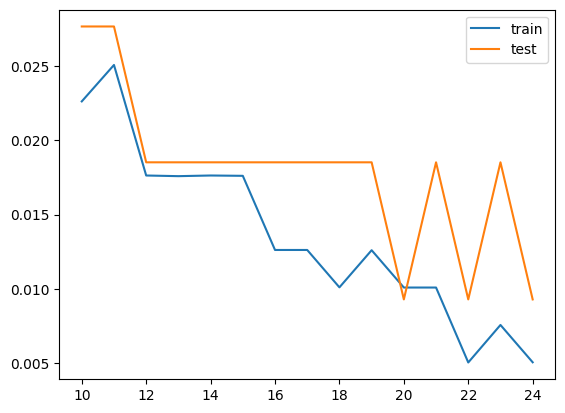

In [44]:
# Plot on F1 Score
plt.plot(list(range(10, 25)), f1_train_list)
plt.plot(list(range(10, 25)), f1_test_list)
plt.legend(['train', 'test'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

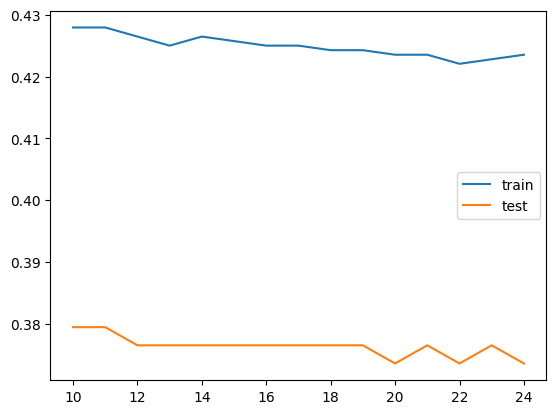

In [45]:
# Plot on Accuracy Score
plt.plot(list(range(10,25)), accuracy_train_list)
plt.plot(list(range(10,25)), accuracy_test_list)
plt.legend(['train','test'])
plt.show

In [46]:
# Apply KNN on best performed K value
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train_bow, y_train)

y_pred_train = KNN.predict(X_train_bow)
accuracy_train = accuracy_score(y_pred_train,y_train)
f1_train = f1_score(y_pred_train,y_train)

y_pred_test = KNN.predict(X_test_bow)
accuracy_test = accuracy_score(y_pred_test,y_test)
f1_test = f1_score(y_pred_test,y_test)

In [47]:
# Apply Classification Report
from sklearn.metrics import classification_report
target_names = ['Postive', 'Negative']

In [48]:
# Show the overall performance on train data
print('Train Data of KNN: ','\n')
print('Accuracy on Train Data: ', accuracy_train, '\n')
print('F1_Score on Train Data: ', f1_train, '\n')
print('Classification Report on Train Data: ', '\n', '\n', classification_report(y_pred_train, y_train, target_names=target_names))

Train Data of KNN:  

Accuracy on Train Data:  0.7102941176470589 

F1_Score on Train Data:  0.7947916666666666 

Classification Report on Train Data:  
 
               precision    recall  f1-score   support

     Postive       0.35      0.90      0.51       226
    Negative       0.97      0.67      0.79      1134

    accuracy                           0.71      1360
   macro avg       0.66      0.79      0.65      1360
weighted avg       0.87      0.71      0.75      1360



In [49]:
# Show the over all performance on test data
print('Test Data of KNN: ','\n')
print('Accuracy on Test Data: ', accuracy_test, '\n' )
print('F1 Score on Test Data: ', f1_test, '\n')
print('Classification Report on Test Data: ', '\n','\n', classification_report(y_pred_test, y_test))

Test Data of KNN:  

Accuracy on Test Data:  0.6441176470588236 

F1 Score on Test Data:  0.7650485436893203 

Classification Report on Test Data:  
 
               precision    recall  f1-score   support

           0       0.17      0.56      0.27        39
           1       0.92      0.65      0.77       301

    accuracy                           0.64       340
   macro avg       0.55      0.61      0.52       340
weighted avg       0.83      0.64      0.71       340



In [50]:
# Apply Confusion Matrix
from sklearn.metrics import confusion_matrix
c_train = confusion_matrix(y_pred_train, y_train)
c_test  = confusion_matrix(y_pred_test, y_test)

In [51]:
# Results of Confusion Matrix on train and test data
print('Confusion Matrix on Train Data: ','\n', c_train, '\n')
print('Confusion Matrix on Test  Data: ', '\n', c_test)

Confusion Matrix on Train Data:  
 [[203  23]
 [371 763]] 

Confusion Matrix on Test  Data:  
 [[ 22  17]
 [104 197]]


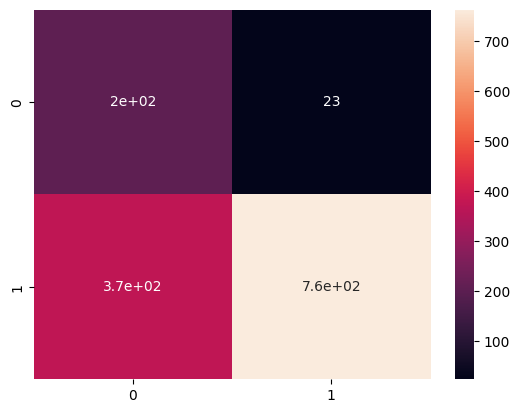

In [52]:
# Apply heatmap on train Data
sns.heatmap(c_train, annot=True)
plt.show()

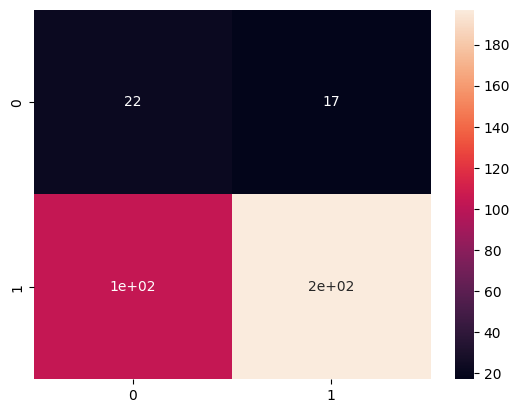

In [53]:
# Apply heatmap on test Data
sns.heatmap(c_test, annot=True)
plt.show()